In [106]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Data Exploration and Understanding

In [107]:
df = pd.read_csv("laptop.csv")

In [108]:
df.head(2)

,Unnamed: 0.1,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232


In [109]:
df.shape
df.size
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      1303 non-null   int64  
 1   Unnamed: 0        1273 non-null   float64
 2   Company           1273 non-null   object 
 3   TypeName          1273 non-null   object 
 4   Inches            1273 non-null   object 
 5   ScreenResolution  1273 non-null   object 
 6   Cpu               1273 non-null   object 
 7   Ram               1273 non-null   object 
 8   Memory            1273 non-null   object 
 9   Gpu               1273 non-null   object 
 10  OpSys             1273 non-null   object 
 11  Weight            1273 non-null   object 
 12  Price             1273 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [110]:
df.drop(columns=['Unnamed: 0.1','Unnamed: 0'],inplace=True)


In [111]:
df.isnull().sum()

Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

In [112]:
df.dropna(inplace=True)
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [113]:
df['Ram'] = df['Ram'].str.replace('GB', '')
df['Weight'] = df['Weight'].str.replace('kg','')
df.replace('?',0, inplace=True)
df['Inches']=df['Inches'].astype('float64')

In [114]:
df['Ram']= df['Ram'].astype('int64')
df['Weight']=df['Weight'].astype("float64")

In [115]:

import warnings
warnings.filterwarnings('ignore')

In [116]:
df.describe()

,Inches,Ram,Weight,Price
count,1273.000000,1273.000000,1273.000000,1273.000000
mean,15.118932,8.462687,2.075986,59955.814073
std,1.999165,5.564408,0.809587,37332.251005
min,0.000000,1.000000,0.000000,9270.720000
25%,14.000000,4.000000,1.500000,31914.720000
50%,15.600000,8.000000,2.040000,52161.120000
75%,15.600000,8.000000,2.320000,79333.387200
max,35.600000,64.000000,11.100000,324954.720000


<Axes: xlabel='Price', ylabel='Density'>

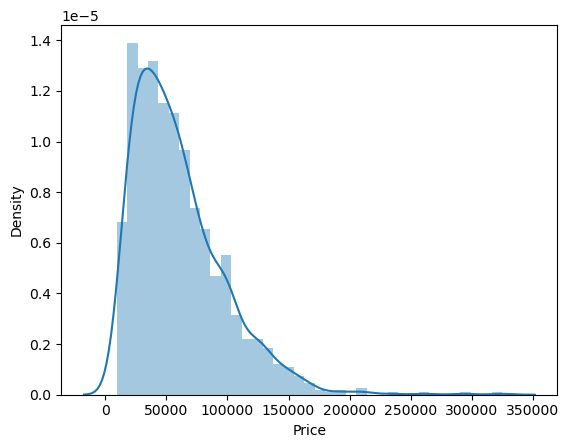

In [117]:
sns.distplot(df['Price'])

<Axes: xlabel='Company'>

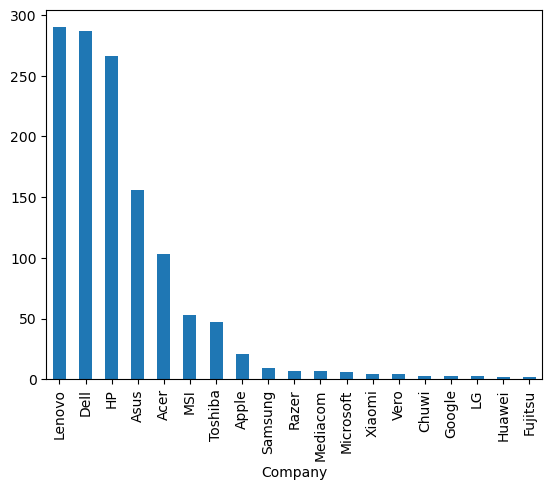

In [118]:
df['Company'].value_counts().plot(kind='bar')

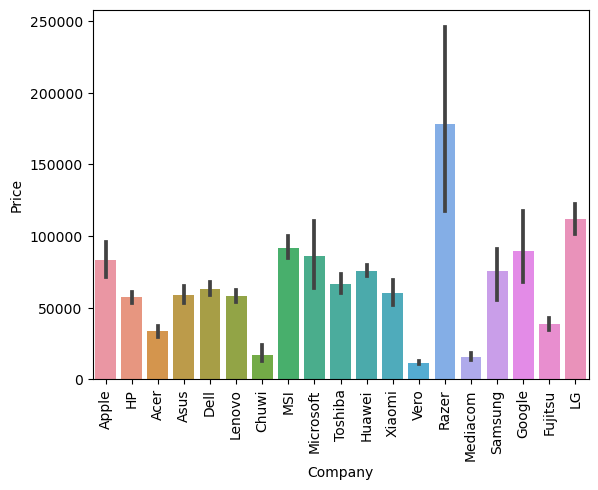

In [119]:
sns.barplot(x=df['Company'], y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='TypeName'>

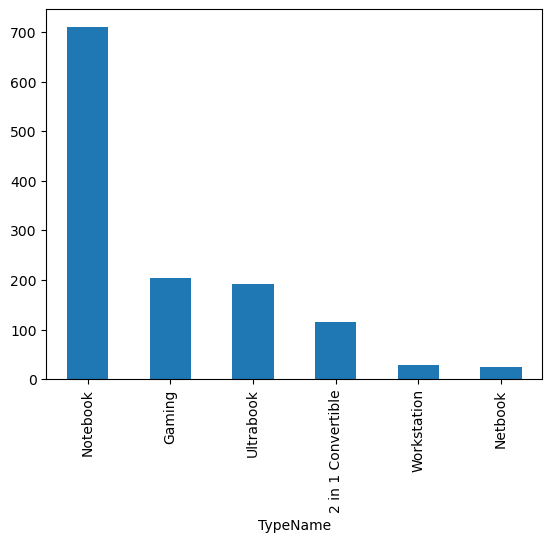

In [120]:
df['TypeName'].value_counts().plot(kind='bar')

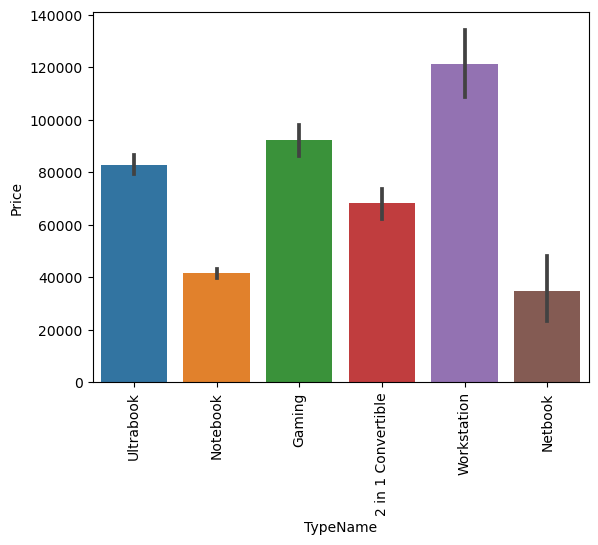

In [121]:
sns.barplot(x=df['TypeName'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='Inches', ylabel='Density'>

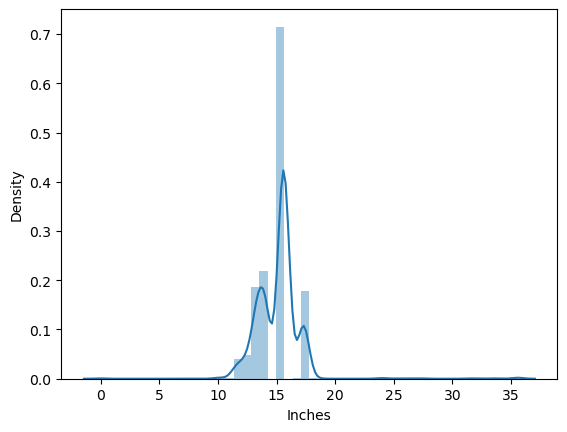

In [122]:
sns.distplot(df['Inches'])

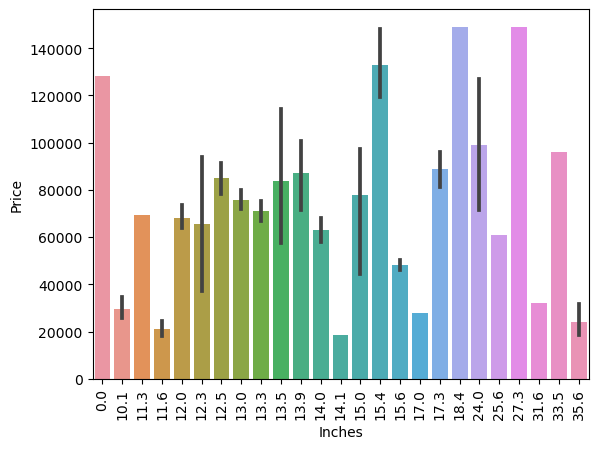

In [123]:
sns.barplot(x=df['Inches'], y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [124]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                495
1366x768                                         274
IPS Panel Full HD 1920x1080                      226
IPS Panel Full HD / Touchscreen 1920x1080         52
Full HD / Touchscreen 1920x1080                   45
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  14
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160                9
4K Ultra HD 3840x2160                              7
IPS Panel 1366x768                                 7
IPS Panel Retina Display 2560x1600                 6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
Touchscreen 2560x1440                              6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Touchscreen 2560x14

In [125]:
df['Touchscreen']=df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

<Axes: xlabel='Touchscreen'>

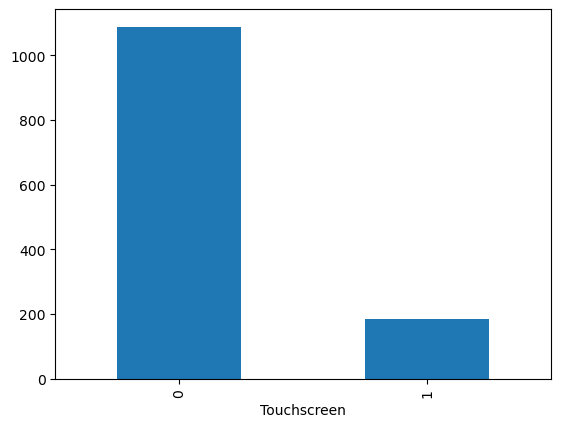

In [126]:
df['Touchscreen'].value_counts().plot(kind='bar')

<Axes: xlabel='Touchscreen', ylabel='Price'>

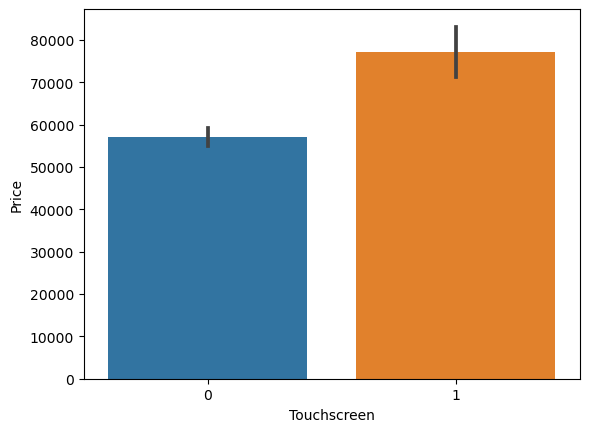

In [127]:
sns.barplot(x=df['Touchscreen'],y=df['Price'])

<Axes: xlabel='IPS'>

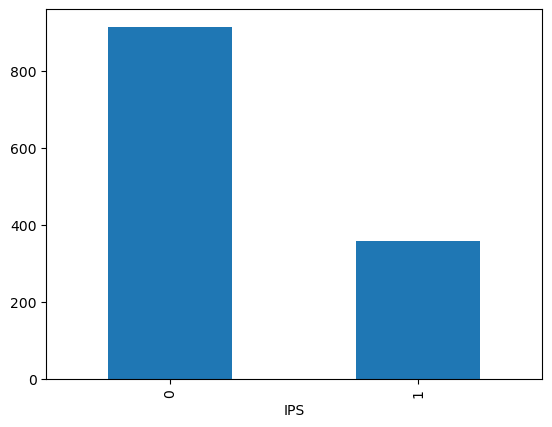

In [128]:
df['IPS'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS Panel' in x else 0)
df['IPS'].value_counts().plot(kind='bar')

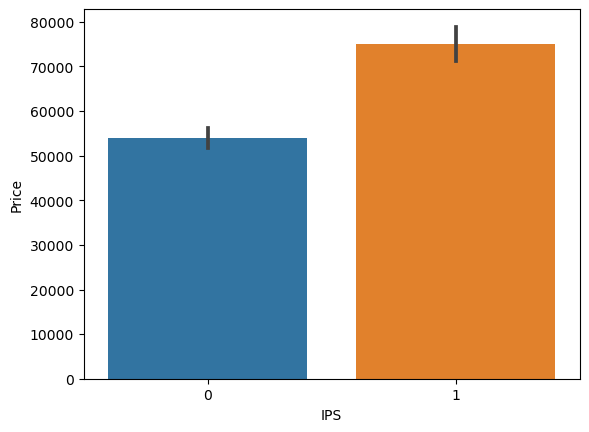

In [129]:
sns.barplot(x=df['IPS'],y=df['Price'])
plt.show()

In [130]:
new = df['ScreenResolution'].str.split('x',n=1, expand=True)
df['X_res']= new[0]
df['Y_res']= new[1]
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,IPS Panel Retina Display 2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900


In [131]:
df['X_res']=df['X_res'].str.replace(',','').str.findall(r'\d+\.?\d+').apply(lambda x:x[0])
df.head(3)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080


In [132]:
df['X_res']=df['X_res'].astype('int32')
df['Y_res']= df['Y_res'].astype('int32')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1273 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1273 non-null   object 
 1   TypeName          1273 non-null   object 
 2   Inches            1273 non-null   float64
 3   ScreenResolution  1273 non-null   object 
 4   Cpu               1273 non-null   object 
 5   Ram               1273 non-null   int64  
 6   Memory            1273 non-null   object 
 7   Gpu               1273 non-null   object 
 8   OpSys             1273 non-null   object 
 9   Weight            1273 non-null   float64
 10  Price             1273 non-null   float64
 11  Touchscreen       1273 non-null   int64  
 12  IPS               1273 non-null   int64  
 13  X_res             1273 non-null   int32  
 14  Y_res             1273 non-null   int32  
dtypes: float64(3), int32(2), int64(3), object(7)
memory usage: 149.2+ KB


In [133]:
df['ppi'] = round(((df['X_res']**2)+(df['Y_res']**2))*0.5/df['Inches']).astype('float')
df.drop(columns=['ScreenResolution', 'X_res','Y_res'], inplace=True)
df.head(2)

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,342617.0
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,108406.0


In [134]:
df['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz     183
Intel Core i7 7700HQ 2.8GHz    142
Intel Core i7 7500U 2.7GHz     128
Intel Core i7 8550U 1.8GHz      72
Intel Core i5 8250U 1.6GHz      68
                              ... 
AMD A9-Series 9420 2.9GHz        1
Intel Core i7 2.2GHz             1
AMD A6-Series 7310 2GHz          1
Intel Atom Z8350 1.92GHz         1
AMD E-Series 9000e 1.5GHz        1
Name: count, Length: 118, dtype: int64

In [135]:
df['Cpu Name']= df['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))
df['Cpu Name'].value_counts()

Cpu Name
Intel Core i7               515
Intel Core i5               410
Intel Core i3               134
Intel Celeron Dual           79
Intel Pentium Quad           27
Intel Core M                 19
AMD A9-Series 9420           12
Intel Celeron Quad            8
AMD A6-Series 9220            8
AMD A12-Series 9720P          7
AMD A8-Series 7410            4
Intel Atom x5-Z8350           4
AMD Ryzen 1700                3
Intel Atom x5-Z8550           3
Intel Pentium Dual            3
AMD A9-Series 9410            3
AMD A10-Series A10-9620P      2
Intel Xeon E3-1505M           2
Intel Atom X5-Z8350           2
AMD A6-Series A6-9220         2
Intel Xeon E3-1535M           2
AMD A9-Series A9-9420         2
AMD A10-Series 9620P          2
AMD E-Series 7110             2
AMD E-Series E2-9000e         2
AMD A10-Series 9600P          2
AMD Ryzen 1600                1
AMD E-Series E2-6110          1
Intel Atom x5-Z8300           1
AMD E-Series 9000e            1
AMD A6-Series 7310            1

In [136]:
def Processor(text):
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
        return text
    elif text.split()[0] == 'Intel':
        return 'Other Intel Processor'
    else:
        return 'AMD Processor'

<Axes: xlabel='Cpu Brand'>

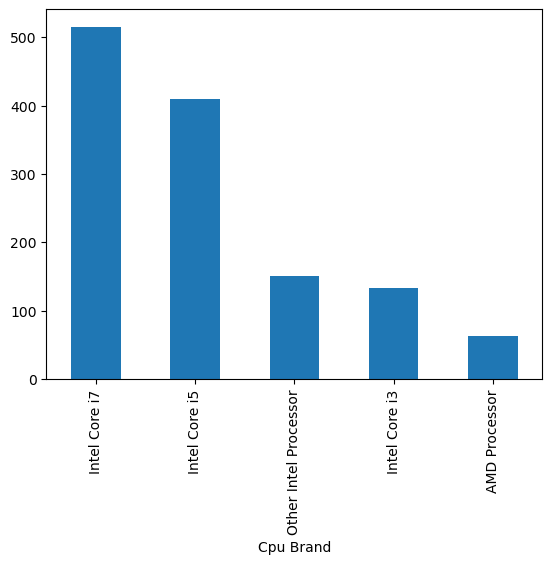

In [137]:
df['Cpu Brand']= df['Cpu Name'].apply(Processor)
df['Cpu Brand'].value_counts().plot(kind='bar')

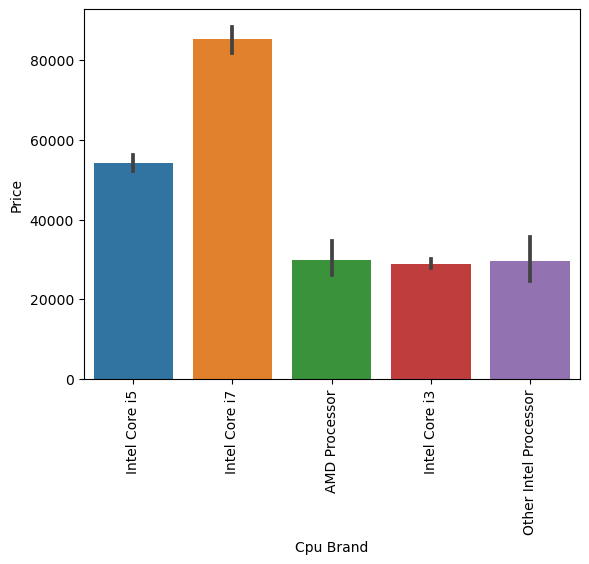

In [138]:
sns.barplot(x=df['Cpu Brand'],y= df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [139]:
df.drop(columns=['Cpu','Cpu Name'], inplace=True)

<Axes: xlabel='Ram'>

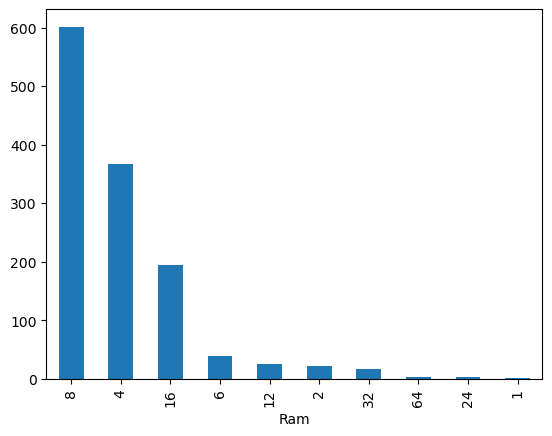

In [140]:
df['Ram'].value_counts().plot(kind='bar')

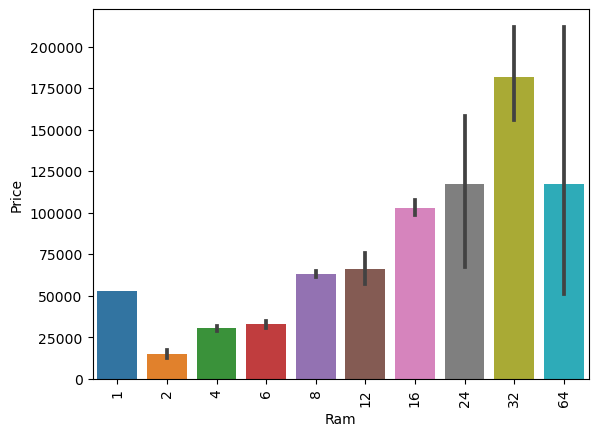

In [141]:
sns.barplot(x=df['Ram'], y = df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [142]:
df['Memory'].value_counts()

Memory
256GB SSD                        401
1TB HDD                          217
500GB HDD                        130
512GB SSD                        116
128GB SSD +  1TB HDD              92
128GB SSD                         74
256GB SSD +  1TB HDD              71
32GB Flash Storage                37
2TB HDD                           16
64GB Flash Storage                14
512GB SSD +  1TB HDD              14
1TB SSD                           13
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          4
128GB Flash Storage                4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
128GB SSD +  2TB HDD               2
256GB SSD +  500GB HDD             2
256GB SSD +  256GB SSD             2
512GB SSD +  256GB SSD         

In [143]:
df['Memory']=df['Memory'].astype('str')

In [144]:
df['HDD'] = 0
df['SSD'] = 0
df['Hybrid'] = 0
df['Flash Storage'] = 0 

In [145]:
def update_storage(row):
    ssd, hdd, hybrid, flash_storage = 0,0,0,0
    parts= row.split(' + ')

    for part in parts:

        try:
            if 'SSD' in part:
                ssd += int(part.replace('GB', '').replace('TB', '000').replace('SSD', '').strip())
            elif 'HDD' in part:
                hdd += int(part.replace('GB', '').replace('TB','000').replace('HDD', '').strip())
            elif 'Hybrid' in part:
                hybrid += int(part.replace('GB', '').replace('TB', '000').replace('Hybrid','').strip())
            elif 'Flash Storage' in part:
                flash_storage += int(part.replace('GB', '').replace('TB', '000').replace('Flash Storage', '').strip())

        except ValueError:
            continue
    return pd.Series([ssd, hdd, hybrid, flash_storage])

In [146]:
df[['SSD','HDD','Hybrid', 'Flash Storage']]= df['Memory'].apply(update_storage)

In [147]:
df.drop(columns=['Memory'],inplace= True)
df.head(2)

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,ppi,Cpu Brand,HDD,SSD,Hybrid,Flash Storage
0,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,342617.0,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,13.3,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,108406.0,Intel Core i5,0,0,0,128


In [148]:
df['HDD'].value_counts()

HDD
0       710
1000    397
500     132
2000     32
32        1
128       1
Name: count, dtype: int64

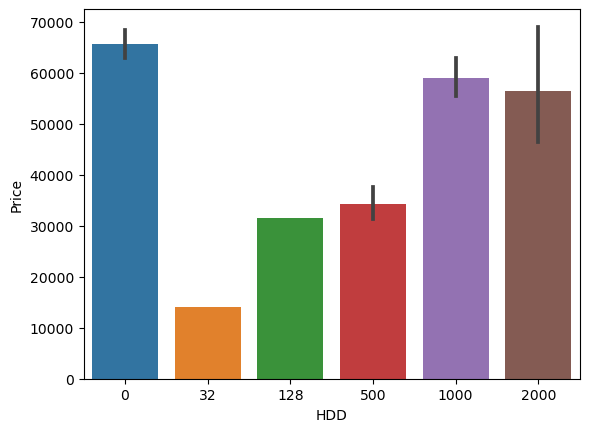

In [149]:
sns.barplot(x=df['HDD'], y=df['Price'])
plt.show()

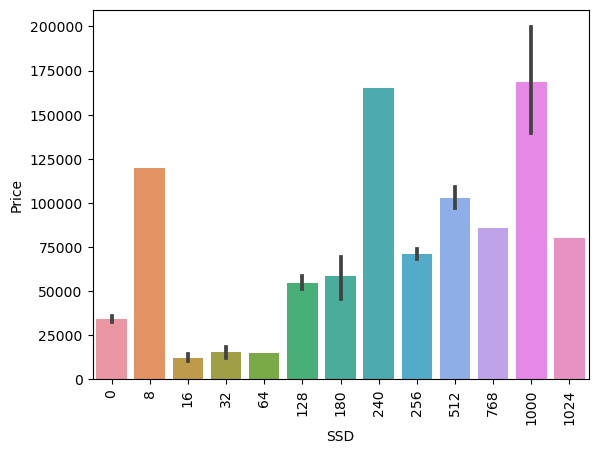

In [150]:
sns.barplot(x=df['SSD'], y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [151]:
import numpy as np
num_df = df.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()
corr_matrix['Price']

Inches           0.032713
Ram              0.685648
Weight           0.174525
Price            1.000000
Touchscreen      0.188994
IPS              0.254851
ppi              0.479208
HDD             -0.094405
SSD              0.668416
Hybrid          -0.004936
Flash Storage   -0.038332
Name: Price, dtype: float64

In [152]:
df.drop(columns=['Flash Storage', 'Hybrid'],inplace= True) # as they have negative correlation with price

In [153]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      271
Intel HD Graphics 520      181
Intel UHD Graphics 620      66
Nvidia GeForce GTX 1050     64
Nvidia GeForce GTX 1060     48
                          ... 
AMD Radeon R5 520            1
AMD Radeon R7                1
Intel HD Graphics 540        1
AMD Radeon 540               1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [154]:
df['Gpu Brand'] = df['Gpu'].apply(lambda x: x.split()[0])

In [155]:
df['Gpu Brand'].value_counts()

Gpu Brand
Intel     703
Nvidia    393
AMD       176
ARM         1
Name: count, dtype: int64

In [156]:
df = df[df['Gpu Brand'] != 'ARM']

<Axes: xlabel='Gpu Brand'>

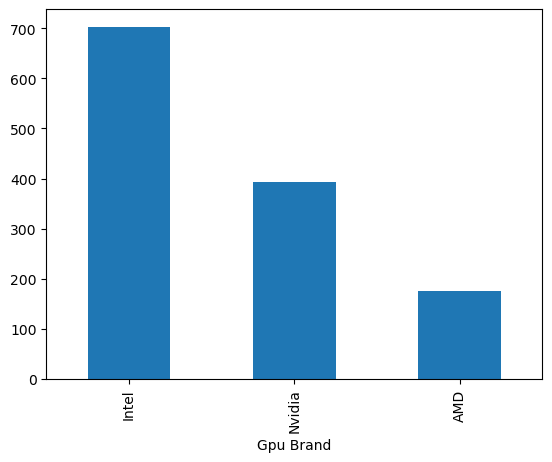

In [157]:
df['Gpu Brand'].value_counts().plot(kind='bar')

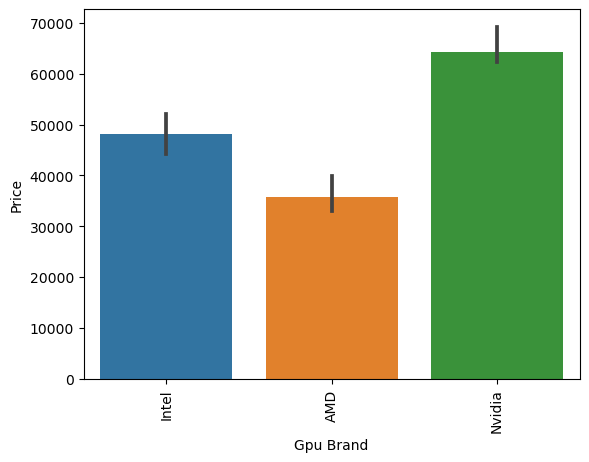

In [158]:
sns.barplot(x=df['Gpu Brand'], y=df['Price'],estimator=np.median)
plt.xticks(rotation= 'vertical')
plt.show()

In [159]:
df.drop(columns=['Gpu'], inplace = True)

In [160]:
df['OpSys'].value_counts()

OpSys
Windows 10      1047
No OS             63
Linux             61
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            1
Name: count, dtype: int64

In [161]:
def system(text):
    if text == 'Windows 10' or text == 'Windows 7' or text == 'Windows 10 S':
        return 'Windows'
    elif text == 'macOS' or text == 'Mac OS X':
        return 'Mac'
    else:
        return 'Other/ No OS/ Linux'

In [162]:
df['System']= df['OpSys'].apply(system)

In [163]:
df.drop(columns=['OpSys'], inplace = True)
df.head(3)

,Company,TypeName,Inches,Ram,Weight,Price,Touchscreen,IPS,ppi,Cpu Brand,HDD,SSD,Gpu Brand,System
0,Apple,Ultrabook,13.3,8,1.37,71378.6832,0,1,342617.0,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,13.3,8,1.34,47895.5232,0,0,108406.0,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,15.6,8,1.86,30636.0000,0,0,155538.0,Intel Core i5,0,256,Intel,Other/ No OS/ Linux


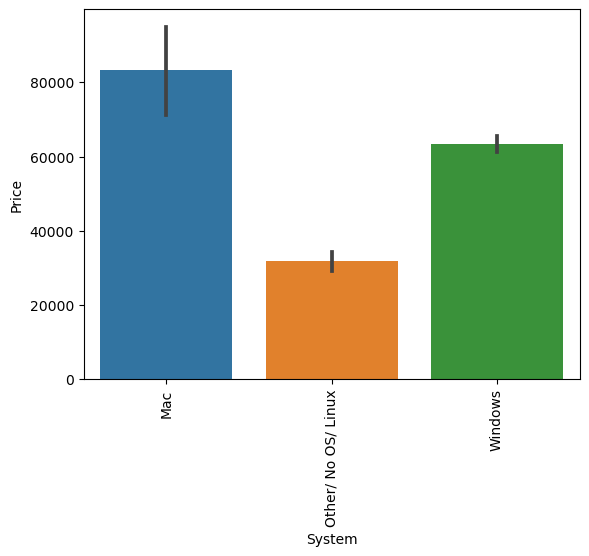

In [164]:
sns.barplot(x=df['System'], y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

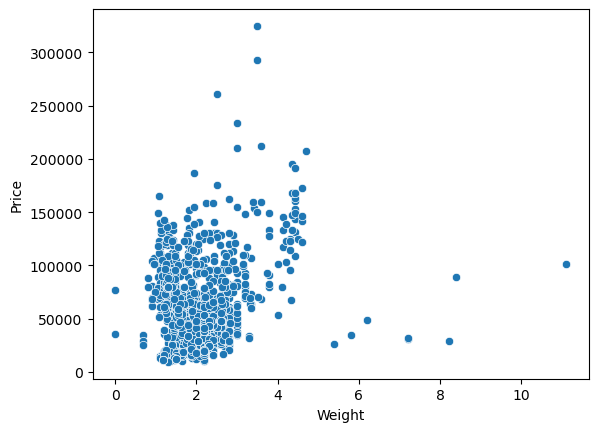

In [165]:
sns.scatterplot(x=df['Weight'], y=df['Price'])
plt.show()

In [166]:
import numpy as np
num_df = df.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()
corr_matrix['Price']

Inches         0.032006
Ram            0.685521
Weight         0.174046
Price          1.000000
Touchscreen    0.190738
IPS            0.255987
ppi            0.480471
HDD           -0.094865
SSD            0.668271
Name: Price, dtype: float64

<Axes: >

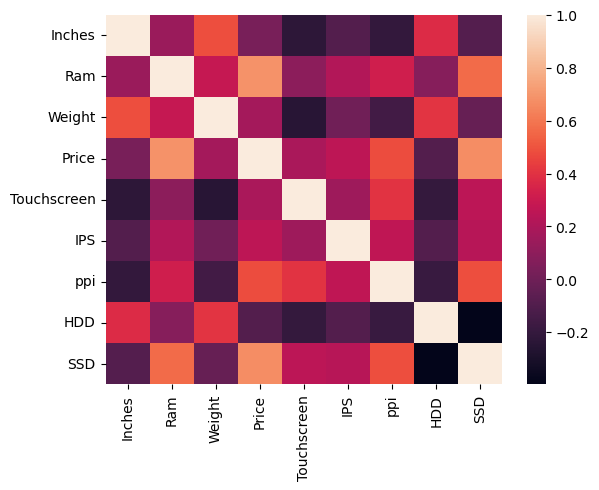

In [167]:
num_df = df.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()
#heat = corr_matrix[['Price']]
sns.heatmap(corr_matrix)

<Axes: xlabel='Price', ylabel='Density'>

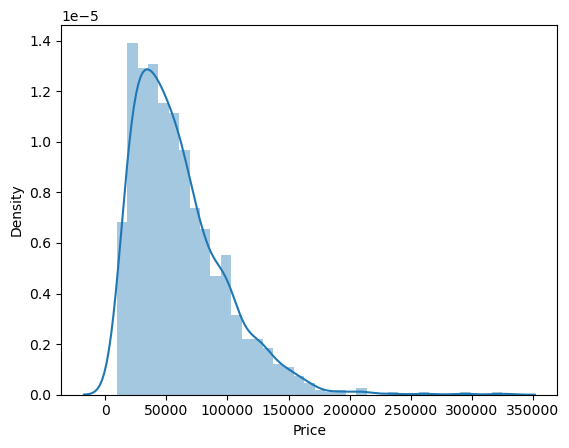

In [168]:
sns.distplot(df['Price'])

<Axes: xlabel='Price', ylabel='Density'>

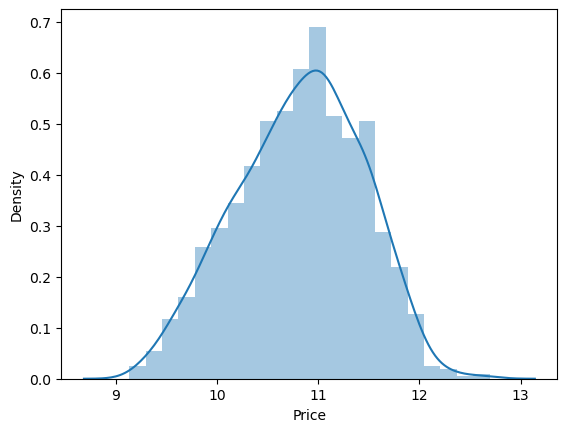

In [169]:
sns.distplot(np.log(df['Price']))

In [170]:
df['TypeName'].value_counts()

TypeName
Notebook              710
Gaming                203
Ultrabook             191
2 in 1 Convertible    115
Workstation            29
Netbook                24
Name: count, dtype: int64

In [171]:
def typename(text):
    if text == '2 in 1 Convertible':
        return 'Convertible'
    else:
        return text

In [172]:
df['TypeName'] = df['TypeName'].apply(typename)

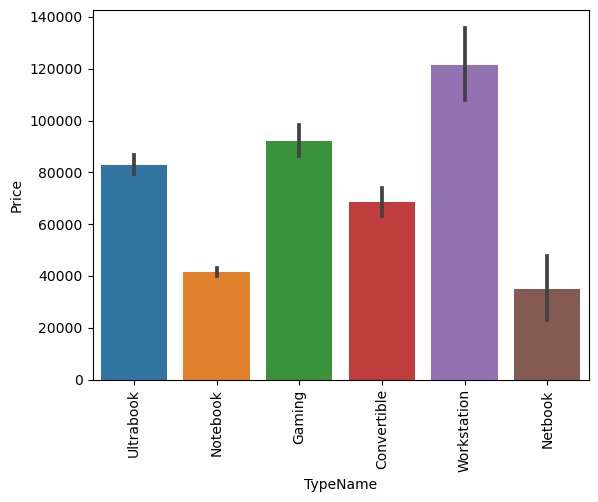

In [173]:
sns.barplot(x = df['TypeName'], y = df['Price'])
plt.xticks(rotation= 'vertical')
plt.show()

In [174]:
df.head()

,Company,TypeName,Inches,Ram,Weight,Price,Touchscreen,IPS,ppi,Cpu Brand,HDD,SSD,Gpu Brand,System
0,Apple,Ultrabook,13.3,8,1.37,71378.6832,0,1,342617.0,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,13.3,8,1.34,47895.5232,0,0,108406.0,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,15.6,8,1.86,30636.0000,0,0,155538.0,Intel Core i5,0,256,Intel,Other/ No OS/ Linux
3,Apple,Ultrabook,15.4,16,1.83,135195.3360,0,1,374494.0,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,13.3,8,1.37,96095.8080,0,1,342617.0,Intel Core i5,0,256,Intel,Mac


In [175]:
print(df.describe().round())

       Inches     Ram  Weight     Price  Touchscreen     IPS       ppi  \
count  1272.0  1272.0  1272.0    1272.0       1272.0  1272.0    1272.0   
mean     15.0     8.0     2.0   59975.0          0.0     0.0       inf   
std       2.0     6.0     1.0   37340.0          0.0     0.0       NaN   
min       0.0     1.0     0.0    9271.0          0.0     0.0   34491.0   
25%      14.0     4.0     2.0   31915.0          0.0     0.0  105853.0   
50%      16.0     8.0     2.0   52161.0          0.0     0.0  155538.0   
75%      16.0     8.0     2.0   79347.0          0.0     1.0  173314.0   
max      36.0    64.0    11.0  324955.0          1.0     1.0       inf   

          HDD     SSD  
count  1272.0  1272.0  
mean    414.0   183.0  
std     517.0   187.0  
min       0.0     0.0  
25%       0.0     0.0  
50%       0.0   256.0  
75%    1000.0   256.0  
max    2000.0  1024.0  


In [176]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=['ppi'], inplace=True)


In [177]:
X = df.drop('Price', axis=1)
y = np.log(df['Price'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [178]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
#categorical columns

cat_onehot = ['Company', 'TypeName', 'Gpu Brand', 'System']
cat_ordinal = ['Cpu Brand']

cpu_categories = [['Other Intel Processor', 'Intel Core i3', 'Intel Core i5', 'Intel Core i7', 'AMD Processor']]  


# applying column transformer to categorical columns
preprocessor = ColumnTransformer(
            transformers=[
                ('Onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_onehot),
                ('Ordinal', OrdinalEncoder(categories= cpu_categories), cat_ordinal )
                ], 
                remainder = 'passthrough'
        )





In [179]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,VotingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,root_mean_squared_error

In [180]:
# Building pipeline and fitting models

model1 = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('LinearRegression', LinearRegression())
    ])
model1.fit(X_train, y_train)


model2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('DecisionTreeRegression', DecisionTreeRegressor())
])
model2.fit(X_train, y_train)

model3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('SVM', SVR(kernel='rbf', C=10000, epsilon=0.1))
])
model3.fit(X_train, y_train)

model4= Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('GradientBoosting', GradientBoostingRegressor(n_estimators=100,max_features=0.5))
])
model4.fit(X_train, y_train)

model5 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('Random Forest', RandomForestRegressor(
            n_estimators=500,        
            max_depth=14,            # limit depth to avoid overfitting
            min_samples_split=2,     # require at least 5 samples to split
            min_samples_leaf=1,      # require at least 2 samples per leaf
            max_features='sqrt',     # consider sqrt(n_features) at each split
            bootstrap=True,          # use bootstrapped samples
            random_state=42
    ))
])
model5.fit(X_train, y_train)

rf =RandomForestRegressor(n_estimators=500,max_depth=14,min_samples_split=2, min_samples_leaf=1,max_features='sqrt',bootstrap=True,random_state=42)
gbdt =GradientBoostingRegressor(n_estimators=100,max_features=0.5)
xgb =XGBRegressor(n_estimators=1100,learning_rate=0.01,max_depth=7,subsample=0.8,colsample_bytree=0.6,n_jobs=-1)

model6 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('VotingRegressor',VotingRegressor([('rf',rf), ('gbdt', gbdt), ('xgb', xgb)], weights=[3,1,4]))
])
model6.fit(X_train, y_train)


model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('XGBoost', XGBRegressor(
        n_estimators=1100,         # Increase trees
    learning_rate=0.01,        # Lower learning rate for better precision
    max_depth=7,               # Prevent overfitting
    subsample=0.8,             # Use 80% of data per tree
    colsample_bytree=0.6,      # Use 80% of features per tree
    n_jobs=-1
    ))
])
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('XGBoost', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Onehot', ...), ('Ordinal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [181]:
import numpy as np

def model_evaluation(model, X_test, y_test, model_name):
    
    y_log_pred = model.predict(X_test)

    y_actual = np.exp(y_test)
    y_pred_actual = np.exp(y_log_pred)

    log_mae = mean_absolute_error(y_test, y_log_pred)
    r2 = r2_score(y_test, y_log_pred)

    actual_mae = mean_absolute_error(y_actual, y_pred_actual)
    actual_rmse = root_mean_squared_error(y_actual, y_pred_actual)

    print(f"{model_name} :")
    print('='*50)
    print(f"Statistical Log-based:")
    print(f"\tR2 Score       : {r2*100:.2f}%")
    print(f"\tLog MAE        : {log_mae:.4f}")
    
    print('-'*50)
    print(f"Real World Actual Price:")
    print(f"\tActual MAE     : {actual_mae:.2f}")
    print(f"\tActual RMSE    : {actual_rmse:.2f}")
    print('='*50)

In [182]:
model_evaluation(model1, X_test, y_test, 'Linear Regression')
model_evaluation(model2, X_test, y_test, 'DecisionTree Regression')
model_evaluation(model3, X_test, y_test, 'SUpport Vector Machine')

Linear Regression :
Statistical Log-based:
	R2 Score       : 74.13%
	Log MAE        : 0.2364
--------------------------------------------------
Real World Actual Price:
	Actual MAE     : 16517.50
	Actual RMSE    : 32796.37
DecisionTree Regression :
Statistical Log-based:
	R2 Score       : 79.93%
	Log MAE        : 0.1947
--------------------------------------------------
Real World Actual Price:
	Actual MAE     : 12668.94
	Actual RMSE    : 22664.65
SUpport Vector Machine :
Statistical Log-based:
	R2 Score       : 61.33%
	Log MAE        : 0.3020
--------------------------------------------------
Real World Actual Price:
	Actual MAE     : 17239.52
	Actual RMSE    : 24733.22


In [183]:
model_evaluation(model4, X_test, y_test, 'Gradient Boosting')
model_evaluation(model5, X_test, y_test, 'Random Forest Regressor')
model_evaluation(model6, X_test, y_test, 'Voting Regressor')

Gradient Boosting :
Statistical Log-based:
	R2 Score       : 87.68%
	Log MAE        : 0.1666
--------------------------------------------------
Real World Actual Price:
	Actual MAE     : 10643.28
	Actual RMSE    : 16869.04
Random Forest Regressor :
Statistical Log-based:
	R2 Score       : 89.81%
	Log MAE        : 0.1466
--------------------------------------------------
Real World Actual Price:
	Actual MAE     : 9639.97
	Actual RMSE    : 16489.44
Voting Regressor :
Statistical Log-based:
	R2 Score       : 90.64%
	Log MAE        : 0.1390
--------------------------------------------------
Real World Actual Price:
	Actual MAE     : 9276.64
	Actual RMSE    : 15848.35


In [184]:
model_evaluation(model, X_test, y_test, 'XGBoost')

XGBoost :
Statistical Log-based:
	R2 Score       : 90.85%
	Log MAE        : 0.1335
--------------------------------------------------
Real World Actual Price:
	Actual MAE     : 9127.36
	Actual RMSE    : 15848.51


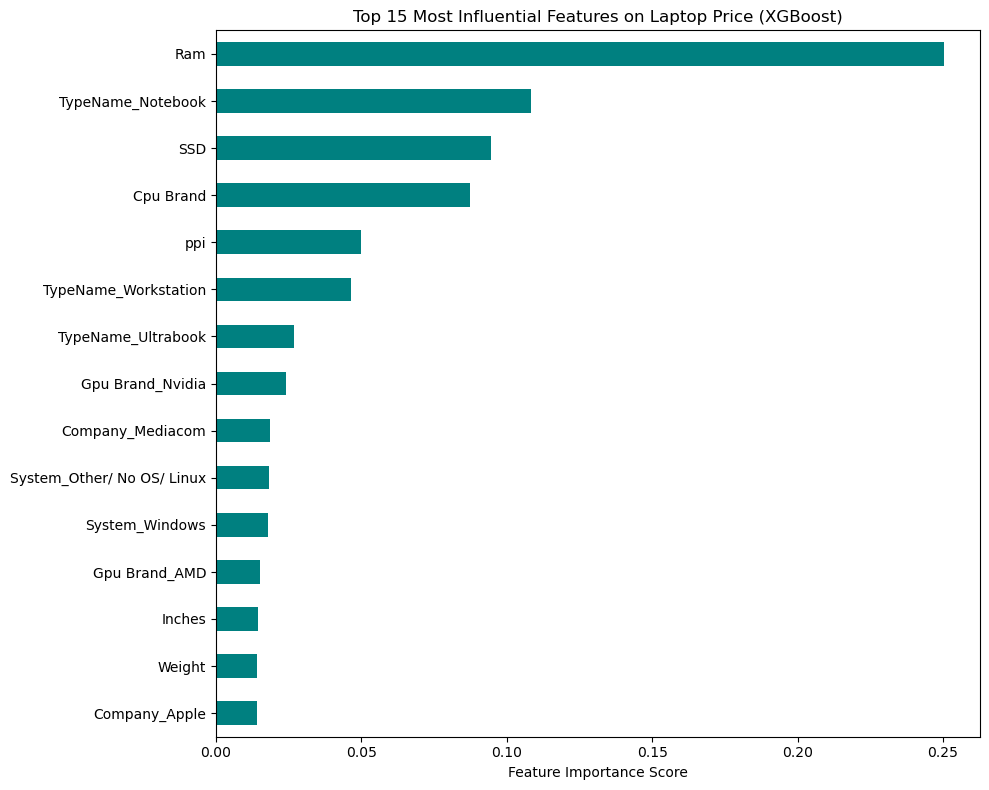

In [185]:

all_features = model.named_steps['preprocessor'].get_feature_names_out()

# Get importance from the XGBoost regressor
importances = model.named_steps['XGBoost'].feature_importances_

# Create a Series
feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)

# cleaning the labels (removing the 'onehot__' or 'remainder__' prefix for a cleaner plot)
feat_imp.index = [name.split('__')[-1] for name in feat_imp.index]

plt.figure(figsize=(10, 8))
feat_imp.head(15).plot(kind='barh', color='teal')
plt.gca().invert_yaxis() # Highest importance at the top
plt.title("Top 15 Most Influential Features on Laptop Price (XGBoost)")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()

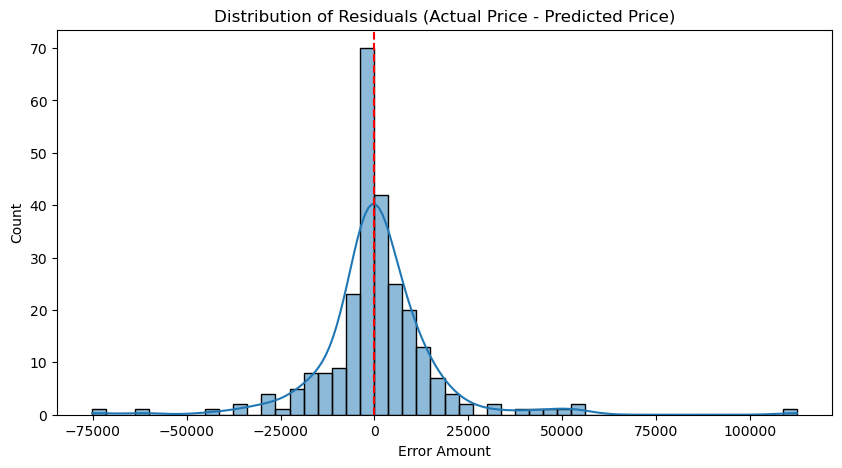

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

y_log_pred = model.predict(X_test)
y_actual = np.exp(y_test)
y_pred_actual = np.exp(y_log_pred)
residuals = y_actual - y_pred_actual

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Residuals (Actual Price - Predicted Price)')
plt.xlabel('Error Amount')
plt.show()

## Exporting the Model

In [ ]:
# import pickle

# with open('df.pkl', 'wb') as f:
#     pickle.dump(df, f)
# print("DataFrame saved successfully!")


DataFrame saved successfully!


In [ ]:
# with open('laptop_price_pickle.pkl', 'wb') as f:
#     pickle.dump(model, f)
# print('model pickle success.')

model pickle success.
